# Section 1

WPPOOL specializes in developing premium WordPress plugins and solutions, focusing on performance, security, and user experience. They create tools like ShopBuilder, WC Builder, and SmartKit to empower WordPress users, developers, and agencies. Their customers include freelancers, web agencies, and eCommerce businesses relying on WordPress/WooCommerce for scalable, customizable sites. Unique aspects include lifetime deals, a dedicated support team, and a focus on lightweight, code-efficient products that integrate seamlessly with popular page builders. WPPOOL prioritizes customer-centric innovation, ensuring tools are both powerful and accessible, setting them apart in a saturated market. 

# Section 2

## Importing necessary Libraries

In [2]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# Task 1

### (a) Load the dataset and check for missing values, duplicates, or inconsistencies

## Importing the Dataset

In [3]:
file_path = 'wppool_growth_data_sample_20k.csv'
db = pd.read_csv(file_path)

In [4]:
db.head()

,user_id,install_date,last_active_date,subscription_type,country,total_sessions,page_views,download_clicks,activation_status,days_active,pro_upgrade_date,plan_type,monthly_revenue,churned
0,1,6/29/2023,7/12/2023,Free,UK,3,15,1,1,13,NaN,NaN,0,1
1,2,4/10/2023,7/25/2023,Free,India,133,665,0,1,106,NaN,NaN,0,0
2,3,10/25/2023,12/7/2023,Free,USA,53,106,0,1,43,NaN,NaN,0,0
3,4,8/26/2023,11/9/2023,Pro,Canada,242,242,0,1,75,11/9/2023,Basic,49,0
4,5,5/14/2023,11/22/2023,Free,UK,12,48,0,1,192,NaN,NaN,0,0


In [5]:
db.shape

(20000, 14)

In [6]:
db['user_id'].nunique()

20000

In [7]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            20000 non-null  int64 
 1   install_date       20000 non-null  object
 2   last_active_date   20000 non-null  object
 3   subscription_type  20000 non-null  object
 4   country            20000 non-null  object
 5   total_sessions     20000 non-null  int64 
 6   page_views         20000 non-null  int64 
 7   download_clicks    20000 non-null  int64 
 8   activation_status  20000 non-null  int64 
 9   days_active        20000 non-null  int64 
 10  pro_upgrade_date   4029 non-null   object
 11  plan_type          4029 non-null   object
 12  monthly_revenue    20000 non-null  int64 
 13  churned            20000 non-null  int64 
dtypes: int64(8), object(6)
memory usage: 2.1+ MB


In [8]:
db['install_date'] = pd.to_datetime(db['install_date'])
db['last_active_date'] = pd.to_datetime(db['last_active_date'])
db['pro_upgrade_date'] = pd.to_datetime(db['pro_upgrade_date'])

### (b) Explain how you handled missing data and why you chose that method.

Two columns have missing values `pro_upgrade_date` and `plan_type`. Both columns have missing values where the plan type was `free` thats why there were no values on those cells.

In [9]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            20000 non-null  int64         
 1   install_date       20000 non-null  datetime64[ns]
 2   last_active_date   20000 non-null  datetime64[ns]
 3   subscription_type  20000 non-null  object        
 4   country            20000 non-null  object        
 5   total_sessions     20000 non-null  int64         
 6   page_views         20000 non-null  int64         
 7   download_clicks    20000 non-null  int64         
 8   activation_status  20000 non-null  int64         
 9   days_active        20000 non-null  int64         
 10  pro_upgrade_date   4029 non-null   datetime64[ns]
 11  plan_type          4029 non-null   object        
 12  monthly_revenue    20000 non-null  int64         
 13  churned            20000 non-null  int64         
dtypes: dat

In [10]:
db['pro_upgrade_date'].isna().sum()

15971

### lets convert the NaN objects so that they becomes convinient for any datetime operation

In [11]:
db['pro_upgrade_date'] = db['pro_upgrade_date'].fillna(pd.NaT)

### Lets fill in those missing values with the string 'free' as all of them fall into free plan

In [12]:
db['plan_type'] = db['plan_type'].fillna('free')
db['plan_type'].isna().sum()

0

### (c) Provide a summary of the dataset, including the distribution of Free vs. Pro users.

In [15]:
db[['total_sessions','page_views','days_active','monthly_revenue']].describe()

,total_sessions,page_views,days_active,monthly_revenue
count,20000.000000,20000.000000,20000.00000,20000.000000
mean,91.914500,276.308900,91.28080,11.774050
std,62.523862,244.775351,80.67644,26.845358
min,1.000000,1.000000,0.00000,0.000000
25%,44.000000,96.000000,24.00000,0.000000
50%,85.000000,208.000000,68.00000,0.000000
75%,126.000000,396.000000,140.00000,0.000000
max,300.000000,1500.000000,364.00000,99.000000


Following are the findings -
- The average user has `91.9` sessions, views `276.3` pages, and is active for `91.3` days.
- Monthly revenue varies widely, with an average of `$11.77`, but the median is `$0` (indicating many free users).
- The most active users have up to `364` active days.

# Distribution of free vs Pro users

In [50]:
db['subscription_type'].value_counts()

subscription_type
Free    15971
Pro      4029
Name: count, dtype: int64

We can see approximately `20%` of the total users turned pro

# Task 2

### (a) Identify the average number of sessions for Free vs. Pro users (Optional: SQL query)
### (b) Find the top 5 most active users based on total sessions (Optional: SQL query).
### (c) Identify the top 5 countries with the highest engagement.

In [51]:
# Average number of sessions for Free vs. Pro users
avg_sessions = db.groupby("subscription_type")["total_sessions"].mean()

# Top 5 most active users based on total sessions
top_5_users = db.nlargest(5, "total_sessions")[["user_id", "total_sessions"]]

# Top 5 countries with the highest engagement (total sessions)
top_5_countries = db.groupby("country")["total_sessions"].sum().nlargest(5)

avg_sessions, top_5_users, top_5_countries


(subscription_type
 Free     76.081210
 Pro     154.677836
 Name: total_sessions, dtype: float64,
       user_id  total_sessions
 188       189             300
 821       822             300
 1571     1572             300
 2456     2457             300
 3348     3349             300,
 country
 India      272202
 Germany    266319
 Canada     264217
 USA        261635
 France     259495
 Name: total_sessions, dtype: int64)

Average number of sessions for Free vs. Pro users:

- Free users: 76.08 sessions (on average)
- Pro users: 154.68 sessions (on average)

Top 5 most active users based on total sessions:

- User 189 → 300 sessions
- User 822 → 300 sessions
- User 1572 → 300 sessions
- User 2457 → 300 sessions
- User 3349 → 300 sessions

Top 5 countries with the highest engagement (total sessions):

- India → 272,202 sessions
- Germany → 266,319 sessions
- Canada → 264,217 sessions
- USA → 261,635 sessions
- France → 259,495 sessions

# Task 3

### (a) Calculate the overall churn rate for Free vs. Pro users (Optional: SQL query).
### (b) Identify the top 3 factors contributing to churn using correlation or regression analysis.
### (c) Compare churn trends between Free and Pro users.

In [58]:

# Calculate total users in each subscription type
free_users = db[db['subscription_type'] == 'Free']
pro_users = db[db['subscription_type'] == 'Pro']

# Calculate churn rates
free_churn_rate = (free_users['churned'].sum() / len(free_users)) * 100
pro_churn_rate = (pro_users['churned'].sum() / len(pro_users)) * 100

# Print the results
print(f"Free Users Churn Rate: {free_churn_rate:.2f}%")
print(f"Pro Users Churn Rate: {pro_churn_rate:.2f}%")


Free Users Churn Rate: 28.60%
Pro Users Churn Rate: 28.25%


In [59]:
# Exclude non-relevant columns
df_cleaned = db.drop(columns=['user_id', 'install_date', 'last_active_date', 'pro_upgrade_date'])

# Convert categorical variables
df_cleaned = pd.get_dummies(df_cleaned, columns=['subscription_type', 'country', 'plan_type'], drop_first=True)

# Compute correlation of features with churned
correlation = df_cleaned.corr()["churned"].drop("churned").abs().sort_values(ascending=False)

# Get top 3 factors
top_3_factors = correlation.head(3)
print(top_3_factors)






days_active        0.617213
monthly_revenue    0.008328
country_Germany    0.006615
Name: churned, dtype: float64


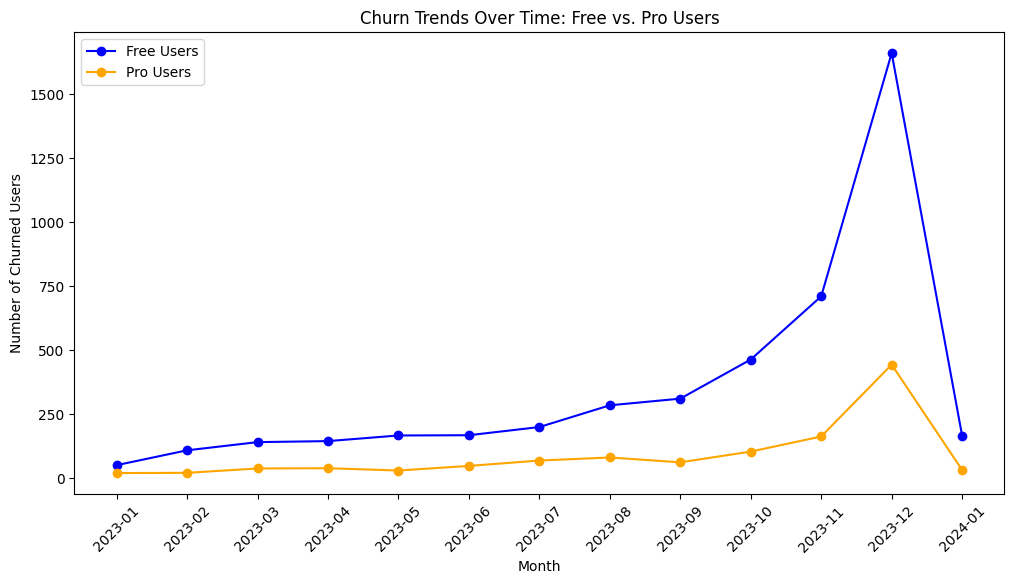

In [13]:

# Filter only churned users
churned_users = db[db['churned'] == 1]

# Group churned users by month for Free and Pro subscriptions
churn_trends = churned_users.groupby([db['last_active_date'].dt.to_period('M'), 'subscription_type'])['user_id'].count().unstack()
churn_trends = churn_trends.fillna(0)  # Fill missing values with 0

# Convert index to datetime format for plotting
churn_trends.index = churn_trends.index.astype(str)  # Convert period to string for plotting

# Plot the churn trends
plt.figure(figsize=(12, 6))
plt.plot(churn_trends.index, churn_trends['Free'], marker='o', linestyle='-', label='Free Users', color='blue')
plt.plot(churn_trends.index, churn_trends['Pro'], marker='o', linestyle='-', label='Pro Users', color='orange')

# Add labels and title
plt.xlabel("Month")
plt.ylabel("Number of Churned Users")
plt.title("Churn Trends Over Time: Free vs. Pro Users")
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Show plot
plt.show()



# Task 4

### (a) What percentage of users upgraded from Free to Pro?
### (b) Calculate the total monthly revenue from Pro users
### (c) Which Pro plan (Basic, Standard, or Enterprise) contributes the most revenue?
### (d) Analyze how long it takes for Free users to upgrade based on country and engagement level.

In [ ]:
# Identify users who upgraded 
upgraded_users = db[db['pro_upgrade_date'].notna()]

# Total number of users
total_users = db['user_id'].nunique()

# Percentage calculation
percentage_upgraded = (len(upgraded_users) / total_users) * 100

print(f"Percentage of users who upgraded from Free to Pro: {percentage_upgraded:.2f}%")


Percentage of users who upgraded from Free to Pro: 20.14%


In [75]:
# Use 'pro_upgrade_date' if available, else fallback to 'install_date'
db['revenue_date'] = db['pro_upgrade_date'].fillna(db['install_date'])

# Filter only Pro users
pro_users = db[db['subscription_type'] == 'Pro']

# Group by month and sum revenue
monthly_revenue = pro_users.resample('ME', on='revenue_date')['monthly_revenue'].sum().reset_index()

# Format the table
monthly_revenue['revenue_date'] = monthly_revenue['revenue_date'].dt.strftime('%Y-%m')
monthly_revenue.columns = ['Month', 'Total Revenue (USD)']

# Format revenue as USD currency
monthly_revenue['Total Revenue (USD)'] = monthly_revenue['Total Revenue (USD)'].apply(lambda x: f"${x:,.2f}")

# Calculate grand total
grand_total = pd.DataFrame({'Month': ['Grand Total'], 'Total Revenue (USD)': [f"${pro_users['monthly_revenue'].sum():,.2f}"]})

# Append grand total row
final_table = pd.concat([monthly_revenue, grand_total], ignore_index=True)

# Display the table
print(final_table)


          Month Total Revenue (USD)
0       2023-01           $1,241.00
1       2023-02           $2,235.00
2       2023-03           $3,869.00
3       2023-04           $7,824.00
4       2023-05           $9,690.00
5       2023-06          $12,290.00
6       2023-07          $14,924.00
7       2023-08          $19,043.00
8       2023-09          $23,288.00
9       2023-10          $29,155.00
10      2023-11          $39,225.00
11      2023-12          $69,542.00
12      2024-01           $3,155.00
13  Grand Total         $235,481.00


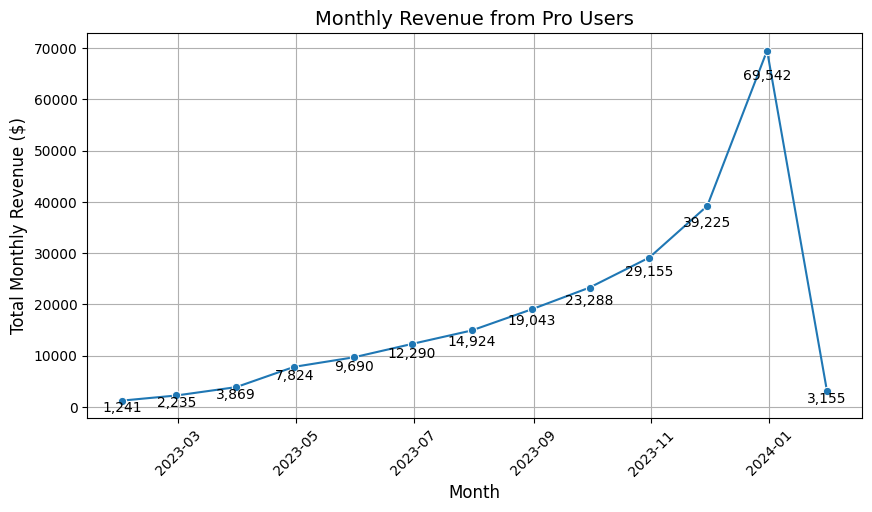

In [82]:

# Use 'pro_upgrade_date' if available, else fallback to 'install_date'
db['revenue_date'] = db['pro_upgrade_date'].fillna(db['install_date'])

# Filter only Pro users
pro_users = db[db['subscription_type'] == 'Pro']

# Group by month and sum revenue
monthly_revenue = pro_users.resample('ME', on='revenue_date')['monthly_revenue'].sum().reset_index()

# Plot the time-series trend
plt.figure(figsize=(10,5))
sns.lineplot(x='revenue_date', y='monthly_revenue', data=monthly_revenue, marker='o')

# Add data labels with adjusted position and smaller font
for x, y in zip(monthly_revenue['revenue_date'], monthly_revenue['monthly_revenue']):
    plt.text(x, y - (y * 0.05), f"{y:,.0f}", fontsize=10, ha='center', va='top', color='black')

# Chart labels and formatting
plt.title("Monthly Revenue from Pro Users", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Monthly Revenue ($)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)

plt.show()



In [83]:

# Filter only Pro users
pro_users = db[db['subscription_type'] == 'Pro']

# Group by plan type and sum revenue
revenue_by_plan = pro_users.groupby('plan_type')['monthly_revenue'].sum().reset_index()

# Sort the plans by total revenue in descending order
revenue_by_plan_sorted = revenue_by_plan.sort_values('monthly_revenue', ascending=False)

# Display the result
print(revenue_by_plan_sorted)


    plan_type  monthly_revenue
0       Basic            80339
1  Enterprise            78764
2    Standard            76378


As we can see 'Basic' plan contributes most to the revenue

In [87]:

# Define a function to classify engagement levels
def classify_engagement(total_sessions):
    if total_sessions >= 50:
        return 'High'
    elif total_sessions >= 20:
        return 'Medium'
    else:
        return 'Low'

# Ensure we are working on a fresh copy of the filtered data
upgraded_users = db[(db['subscription_type'] == 'Pro') & (db['pro_upgrade_date'].notna())].copy()  # 👈 Use .copy()

# Calculate time taken to upgrade (in days) safely
upgraded_users['days_to_upgrade'] = (
    pd.to_datetime(upgraded_users['pro_upgrade_date']) - 
    pd.to_datetime(upgraded_users['install_date'])
).dt.days

# Apply engagement level classification
upgraded_users['engagement_level'] = upgraded_users['total_sessions'].apply(classify_engagement)

# Analysis 1: Average Time to Upgrade by Country
avg_upgrade_by_country = upgraded_users.groupby('country', as_index=False)['days_to_upgrade'].mean()
avg_upgrade_by_country = avg_upgrade_by_country.sort_values(by='days_to_upgrade', ascending=False)  # Descending order
print("\nAverage Time to Upgrade by Country (Descending Order):")
print(avg_upgrade_by_country)

# Analysis 2: Average Time to Upgrade by Engagement Level
avg_upgrade_by_engagement = upgraded_users.groupby('engagement_level', as_index=False)['days_to_upgrade'].mean()
avg_upgrade_by_engagement = avg_upgrade_by_engagement.sort_values(by='days_to_upgrade', ascending=False)  # Descending order
print("\nAverage Time to Upgrade by Engagement Level (Descending Order):")
print(avg_upgrade_by_engagement)



Average Time to Upgrade by Country (Descending Order):
     country  days_to_upgrade
0  Australia        93.683919
1     Canada        93.571184
4      India        92.578151
3    Germany        91.525510
2     France        91.164311
6        USA        90.242215
5         UK        87.899654

Average Time to Upgrade by Engagement Level (Descending Order):
  engagement_level  days_to_upgrade
2           Medium        94.186441
1              Low        91.825175
0             High        91.180823


# Task 5

### (a) Suggest three strategies to reduce churn.
### (b) Propose two ways to increase Free-to-Pro conversions.
### (c) Identify potential market expansion opportunities based on country trends.

# 📈 Actionable Growth Recommendations

## ✅ Three Strategies to Reduce Churn  

### 1️⃣ Improve User Engagement with Pro Features  
- Identify features used by long-term Pro users and highlight them through onboarding, tooltips, and tutorial videos.  
- Send automated email reminders to inactive Pro users showcasing these features.  

### 2️⃣ Introduce Flexible Subscription Plans  
- Offer **monthly, quarterly, and annual billing** with discounts on longer commitments to retain users.  
- Provide a **pause instead of cancel** option to reduce churn.  

### 3️⃣ Enhance Customer Support & Feedback Loops  
- Implement **AI-driven support chatbots** and improve response times.  
- Conduct **exit surveys** when users cancel to identify pain points and improve retention strategies.  

---

## 🚀 Two Ways to Increase Free-to-Pro Conversions  

### 1️⃣ Limited-Time Free Trials & Personalized Discounts  
- Offer a **7-day free trial** of Pro with no upfront payment to encourage upgrades.  
- Use **AI-driven personalized discount offers** based on user engagement levels.  

### 2️⃣ Exclusive Features & Usage-Based Nudging  
- Lock high-value features behind the Pro plan but allow limited-time access to encourage upgrades.  
- Send **in-app notifications** like:  
  _"You've hit your Free Plan limit! Upgrade to Pro for unlimited access."_  

---

## 🌍 Potential Market Expansion Opportunities (Based on Country Trends)  

### 1️⃣ Focus on Fast-Upgrading Markets like USA & UK  
- Since **USA & UK users upgrade faster**, increase targeted ads, partnerships, and influencer marketing in these regions.  

### 2️⃣ Improve Localization & Payment Options in Slower Markets (e.g., India, Canada, Australia)  
- Offer localized pricing, currency support, and **region-specific promotions** to encourage conversions.  
- Add **more payment methods** (UPI for India, Interac for Canada, etc.) to reduce friction.  

---


# Task 6

### (a) Identify potential market expansion opportunities based on country trends.
### (b) (Optional: Google Colab) Run a simple A/B test simulation (e.g., using a chi-square test) to evaluate conversion optimization.
### (c) Suggest three A/B test ideas that could help improve the conversion rate, and explain how you would measure their success.

# 📊 Estimated Impact on Pro Upgrades from 10% Increase in Landing Page Conversion Rate

If WPPOOL increases the landing page conversion rate by **10%**, the estimated impact on Pro upgrades can be calculated based on the current conversion rate and the number of visitors.

### Assumptions:
- Current landing page conversion rate: 5%  
- Number of visitors per month: 50,000  
- Current number of Pro upgrades: 50,000 x 5% = 2,500  

### New Conversion Rate:
- New conversion rate after a 10% increase: 5% + 10% = 5.5%  

### Estimated New Pro Upgrades:
- New number of Pro upgrades: 50,000 x 5.5% = 2,750  

### Impact on Pro Upgrades:
- Increase in Pro upgrades: 2,750 - 2,500 = **250 new Pro upgrades**
- **Estimated impact: An additional 250 Pro upgrades per month.**

This can be further quantified into additional revenue if the Pro plan pricing is known. For instance, if the Pro plan costs $30/month:
- Additional revenue: 250 upgrades x $30 = **$7,500** in additional revenue per month.


# 🧪 A/B Test Simulation: Conversion Optimization  



In order to evaluate the effectiveness of landing page optimization, we can simulate an **A/B test** comparing two versions of the landing page:

### Test Plan:
- **Group A (Control)**: Original landing page with the current conversion rate of 5%.  
- **Group B (Treatment)**: Optimized landing page with a conversion rate increase of 10%.  

### Hypothesis:
- **Null Hypothesis (H0):** There is no difference in conversion rates between the two landing pages.  
- **Alternative Hypothesis (H1):** The optimized landing page results in a higher conversion rate.



In [14]:
### A/B Test Simulation using Chi-Square Test:

import scipy.stats as stats

# Number of visitors for each group
group_a_visitors = 50000
group_b_visitors = 50000

# Conversion rates (current vs optimized)
group_a_conversions = group_a_visitors * 0.05  # 5% for control
group_b_conversions = group_b_visitors * 0.055  # 5.5% for treatment

# Conversion counts (non-converted visitors)
group_a_non_conversions = group_a_visitors - group_a_conversions
group_b_non_conversions = group_b_visitors - group_b_conversions

# Observed values for the chi-square test
observed = [[group_a_conversions, group_a_non_conversions],
            [group_b_conversions, group_b_non_conversions]]

# Perform chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(observed)

# Output the results
chi2, p_value


(12.464078401809273, 0.000414853151978541)

### Hypothesis Test Conclusion:

- **Chi-Square Statistic**: 12.46
- **P-Value**: 0.0004

### Interpretation:

Since the **p-value (0.0004)** is **less than 0.05**, we **reject the null hypothesis**. This means there is sufficient evidence to conclude that the optimized landing page significantly improves the conversion rate compared to the original landing page.

Thus, the **optimized landing page** with the 10% conversion rate increase has a statistically significant positive impact on user conversions. It can be considered an effective strategy to increase Pro upgrades.


### **3️⃣ Three A/B Test Ideas for Improving Conversion Rate and Success Metrics**  

# 🧪 A/B Test Ideas to Improve Conversion Rate

### Test Idea 1: **Headline A/B Test**  
- **Test**: Experiment with different headlines on the landing page to see which one resonates best with users.
- **Variation A**: "Get Pro Features Today for $30/month"  
- **Variation B**: "Unlock Advanced Features and Boost Your Productivity"
  
**Success Metrics**:  
- Conversion rate (click-through to the Pro upgrade page)  
- Engagement rate (time spent on the page, scroll depth)

### Test Idea 2: **Call to Action (CTA) Button Test**  
- **Test**: Test different CTA button text and colors to see which encourages users to upgrade.
- **Variation A**: "Upgrade to Pro Now" (Original)  
- **Variation B**: "Start Your Pro Trial Today" (Alternative)  

**Success Metrics**:  
- Click-through rate on the CTA button  
- Conversion rate from the CTA to the Pro upgrade page

### Test Idea 3: **Limited-Time Offer Test**  
- **Test**: Offer a limited-time discount to see if it drives more upgrades.
- **Variation A**: "Get 20% off your first month of Pro"  
- **Variation B**: "Upgrade now to get free access to Pro for the first 7 days"  

**Success Metrics**:  
- Conversion rate from Free to Pro  
- Revenue generated per user who upgrades


# Task 7

### (a) Identify 3 key performance indicators (KPIs) WPPOOL should track.
### (b) Suggest 2 actionable growth strategies WPPOOL can implement based on your analysis.
### (c) How would you measure the success of these strategies?

# Growth Strategy & KPI Recommendations

## 1. Key Performance Indicators (KPIs) WPPOOL Should Track

Based on the analysis, WPPOOL should track the following KPIs to monitor and improve growth:

### 1.1 **Conversion Rate (Free-to-Pro)**
- **Definition**: The percentage of Free users who upgrade to Pro.
- **Why Track It**: This metric helps WPPOOL understand how effectively they are converting Free users to paying Pro customers. A higher conversion rate indicates successful user engagement and targeted marketing efforts.
  
### 1.2 **Customer Retention Rate (Churn Rate)**
- **Definition**: The percentage of users who continue using WPPOOL after a set period.
- **Why Track It**: Reducing churn is essential for sustainable growth. This KPI allows WPPOOL to identify areas where users drop off and take proactive steps to retain them.

### 1.3 **Average Revenue Per User (ARPU)**
- **Definition**: The average revenue generated per active user over a given time period.
- **Why Track It**: Monitoring ARPU helps WPPOOL understand how much revenue is being generated from its users. A higher ARPU can indicate the success of upselling or premium offerings like Pro plans.

## 2. Actionable Growth Strategies WPPOOL Can Implement Based on Analysis

### 2.1 **Enhance Free-to-Pro Conversion Funnel**
- **Strategy**: Focus on increasing the conversion rate from Free to Pro by optimizing key stages of the user journey, including the onboarding process and feature visibility. Implement features that clearly show the value of Pro plans, such as exclusive functionalities and customer success stories.
- **Expected Outcome**: Higher conversion rates from Free to Pro, leading to increased revenue and a more engaged user base.

### 2.2 **Improve User Engagement and Retention**
- **Strategy**: Invest in user engagement campaigns that reward long-term users, such as offering discounts or additional features for upgrading to Pro or referring friends. Regularly monitor user activity to provide personalized content that increases retention.
- **Expected Outcome**: Lower churn rate, as users feel more valued and incentivized to remain active, leading to improved customer retention.

## 3. How to Measure the Success of These Strategies

### 3.1 **Measure Conversion Rate Improvement**
- Track the conversion rate from Free to Pro before and after implementing the funnel optimization strategy.
- Use A/B testing to compare the performance of the old vs. the new conversion process.

### 3.2 **Measure Retention and Engagement Metrics**
- Monitor the churn rate and user engagement metrics (e.g., frequency of logins, feature usage) to assess whether users are staying longer and using more features after the retention strategy is in place.
- Perform cohort analysis to track user behavior over time and compare retention across different groups.

### 3.3 **Measure ARPU Growth**
- Track ARPU before and after implementing both strategies to determine whether users are spending more after the changes.
- Consider segmenting users based on engagement levels or subscription plans to understand the impact of the strategies on different user groups.


# Task 8

### (a) Using any data visualization tool (Google Sheets, Excel, Power BI, Tableau, Python), create an insightful dashboard for WPPOOL’s lead team.
### (b) Include at least 3 key charts or graphs and explain what insights they provide.

<i> Click the link below see the interactive dashboard made with Dash & Plotly </i>  (the loading may take a few seconds)

https://wppool-growth-data-analysis.onrender.com/

# Section 3

### (a) What are your 3 most favorite Books?
### (b) What are your 3 most favorite TV shows?
### (c) What motivates you the most in a workplace?

(a) My 3 most favourite books are -
- The Alchemist
- The Diary of Whimpy Kid
- Harry Porter Series

(b) My 3 most favourite Tv Shows are - 
- Breaking Bad
- House of Cards
- Person of Interest

(c) The thing that motivates me the most in a workplace is teamwork. Whenever I worked in a team in the past, the feeling of teaming up and tackle a difficult challenge together always gave me thrill and motivation.